In [24]:
%matplotlib inline
import random #随机数工具
import torch
from d2l import torch as d2l

```%matplotlib inline```  
***生成的图标直接显示在笔记中，而不是打开一个新窗口***  
```import random```  
***在线性回归中需要随机打乱数据***  
```d2l```  
***这是李沐老师整合的工具包，比如里面的torch模块，封装了一些常用的绘图，数据处理函数***

## 构建一个人造数据集

In [25]:
def synthetic_data(w, b, num_examples):  #@save
    """生成y=Xw+b+噪声"""
    X = torch.normal(0, 1, (num_examples, len(w)))
    y = torch.matmul(X, w) + b
    y += torch.normal(0, 0.01, y.shape)
    return X, y.reshape((-1, 1))

true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)

***好神奇，只想着用```.format```，```f'```,竟然把这种最原始的输出方式给忘了   
还可以在字符串前面加 ```/n```来换行***

In [41]:
print('features: ',features[0],'\nlable: ',labels[0])

features:  tensor([ 0.4039, -0.9501]) 
lable:  tensor([8.2301])


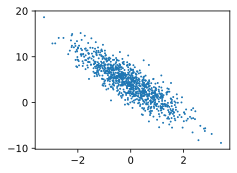

In [27]:
d2l.set_figsize()
d2l.plt.scatter(features[:, 1].detach().numpy(), labels.detach().numpy(), 1);

## 读取数据集
***相当于dataloader的作用***

In [28]:
def data_iter(batch_size, features, labels):
    num_examples = len(features)
    indices = list(range(num_examples))
    # 这些样本是随机读取的，没有特定的顺序
    random.shuffle(indices)
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(
            indices[i: min(i + batch_size, num_examples)])
        yield features[batch_indices], labels[batch_indices]

```for i in range(0, num_examples, batch_size):```  
>range(a,b,c)  
>- a 起始数据  
>- b 终止数据  
>- c 数据间隔

```  yield```作用和return类似  
*但yield返回值时不会中止函数的运行*

## 初始化模型参数

In [29]:
w = torch.normal(0, 0.01, size=(2,1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)

```torch.noraml```***正态分布的随机数生成器***  
> - 0 即```mean```*平均数*  
> - 0.01```std```*标准差*  
> - 设定形状  
> - 需要梯度

```torch.zeros```创建一个全是0的张量
>权重b没有那么讲究，初始值为0即可
>- 1 长度为1的1维张量

## 定义模型

In [30]:
def linreg(X, w, b):  #@save
    """线性回归模型"""
    return torch.matmul(X, w) + b

***X是人造数据集，W是权重  
使用矩阵乘法将X和W乘起来  
再加上b***
>这个也就相当于是网络模型的简化版本

## 定义损失函数

In [31]:
def squared_loss(y_hat, y):  #@save
    """均方损失"""
    return (y_hat - y.reshape(y_hat.shape)) ** 2 / 2

## 定义优化算法

In [32]:
def sgd(params, lr, batch_size):  #@save
    """小批量随机梯度下降"""
    with torch.no_grad():
        for param in params:
            param -= lr * param.grad / batch_size
            param.grad.zero_()

>- params里包含权重w和偏置b
>- lr 传入学习率
>- 传入每个批次数据大小
>- ```with torch.no_grad()优化的时候就不再需要梯度的计算了```
>- para.grad代表往哪个方向误差减小得最快

***```parm=parm-parm```更新权重和偏置的参数***
>把参数回拉

***最后优化完了之后把梯度清零，让下一次的梯度重新计算***

## 训练
***训练的前置操作：加载数据集，初始化权重，偏置，定义损失函数。定义优化算法***

***把学习率，训练轮数，网络模型，损失函数都做为参数传入  
方便后续的修改***

In [33]:
lr = 0.03
num_epochs = 3
net = linreg
loss = squared_loss
batch_size = 10

for epoch in range(num_epochs):
    for X, y in data_iter(batch_size, features, labels):
        l = loss(net(X, w, b), y)  # X和y的小批量损失
        # 因为l形状是(batch_size,1)，而不是一个标量。l中的所有元素被加到一起，
        # 并以此计算关于[w,b]的梯度
        l.sum().backward()
        sgd([w, b], lr, batch_size)  # 使用参数的梯度更新参数
    with torch.no_grad():
        train_l = loss(net(features, w, b), labels)
        print(f'epoch {epoch + 1}, loss {float(train_l.mean()):f}')

epoch 1, loss 0.032265
epoch 2, loss 0.000107
epoch 3, loss 0.000050


```l.sum().backward()```  
**l（损失）是一个批次里所有题目的误差集合（一个向量）。PyTorch 的 backward 必须针对一个具体的“总分”（标量）来计算。所以我们要把这批误差加在一起，求个总分，然后再算梯度。**  

*为什么不用正向求导*  
>“正向”行不通？
>想象一下，你的模型里有 100万个参数（w_1, w_2, ..., w_{100w}）,但最后只输出了 1个损失值（Loss）。  
> 正向求导的逻辑：  每变动一个参数，看一遍结果的变化。  
> 为了算出这 100 万个参数的梯度，你需要把整个模型跑 100 万遍。  
>直白点说：这就像你想知道 100 个调料对汤底味道的影响。  
>正向法是：加一点盐，重熬一锅汤尝尝；加一点糖，再重熬一锅尝尝……这厨房非炸了不可。

*反向求导*
>反向传播（Backward）利用了数学里的链式法则。
>它从结果（Loss）出发，往回推。  
反向求导的逻辑：只跑 1 遍 就能算出所有参数的梯度。  
它先看“味道咸了多少”，然后往回推：这锅汤里盐放多了，而盐是由哪个勺子加进去的？勺子又是谁拿的？  
核心优势：无论你的模型有 100 个参数还是 10 亿个参数，反向传播只需要一次往回传的过程，就能把所有参数的“责任”（梯度）都算出来。

***对比***
|正向求导 (Forward Mode)|反向求导 (Backward Mode)|
|---------------------|-----------------------|
|输入变量少，输出变量多 | 输入变量多，输出变量少|  


```loss = squared_loss```*好聪明的方法，不仅仅可以传一个变量，还可以传一个函数*